# Домашнее задание. Нейросетевая классификация текстов

В этом домашнем задании вам предстоит самостоятельно решить задачу классификации текстов на основе семинарского кода. Мы будем использовать датасет [ag_news](https://paperswithcode.com/dataset/ag-news). Это датасет для классификации новостей на 4 темы: "World", "Sports", "Business", "Sci/Tech".

Установим модуль datasets, чтобы нам проще было работать с данными.

In [1]:
!pip install -q datasets

Импорт необходимых библиотек

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import datasets

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List
import string

import seaborn
seaborn.set(palette='summer')

In [3]:
nltk.download('punkt')
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных
Для вашего удобства, мы привели код обработки датасета в ноутбуке. Ваша задача --- обучить модель, которая получит максимальное возможное качество на тестовой части.

In [5]:
# Загрузим датасет
dataset = datasets.load_dataset('ag_news')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Как и в семинаре, выполним следующие шаги:
* Составим словарь
* Создадим класс WordDataset
* Выделим обучающую и тестовую часть, создадим DataLoader-ы.

In [33]:
words = Counter()

for example in tqdm(dataset['train']['text']):
    # Приводим к нижнему регистру и убираем пунктуацию
    prccessed_text = example.lower().translate(
        str.maketrans('', '', string.punctuation))

    for word in word_tokenize(prccessed_text):
        words[word] += 1


vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
counter_threshold = 5

for char, cnt in words.items():
    if cnt > counter_threshold:
        vocab.add(char)

print(f'Размер словаря: {len(vocab)}')

word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

  0%|          | 0/120000 [00:00<?, ?it/s]

Размер словаря: 27694


In [34]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        processed_text = self.data[idx]['text'].lower().translate(
            str.maketrans('', '', string.punctuation))
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [
            word2ind.get(word, self.unk_id) for word in word_tokenize(processed_text)
            ]
        tokenized_sentence += [self.eos_id]

        train_sample = {
            "text": tokenized_sentence,
            "label": self.data[idx]['label']
        }

        return train_sample

    def __len__(self) -> int:
        return len(self.data)


def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>'], max_len=256) -> torch.Tensor:
    seq_lens = [len(x['text']) for x in input_batch]
    max_seq_len = min(max(seq_lens), max_len)

    new_batch = []
    for sequence in input_batch:
        sequence['text'] = sequence['text'][:max_seq_len]
        for _ in range(max_seq_len - len(sequence['text'])):
            sequence['text'].append(pad_id)

        new_batch.append(sequence['text'])

    sequences = torch.LongTensor(new_batch).to(device)
    labels = torch.LongTensor([x['label'] for x in input_batch]).to(device)

    new_batch = {
        'input_ids': sequences,
        'label': labels
    }

    return new_batch

In [35]:
train_dataset = WordDataset(dataset['train'])

np.random.seed(42)
idx = np.random.choice(np.arange(len(dataset['test'])), 5000)
eval_dataset = WordDataset(dataset['test'].select(idx))

batch_size = 125
train_dataloader = DataLoader(
    train_dataset, shuffle=True, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, shuffle=False, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Постановка задачи
Ваша задача -- получить максимальное возможное accuracy на `eval_dataloader`. Ниже приведена функция, которую вам необходимо запустить для обученной модели, чтобы вычислить качество её работы.

In [17]:
def evaluate(model, eval_dataloader) -> float:
    """
    Calculate accuracy on validation dataloader.
    """

    predictions = []
    target = []
    with torch.no_grad():
        for batch in eval_dataloader:
            logits = model(batch['input_ids'])
            predictions.append(logits.argmax(dim=1))
            target.append(batch['label'])

    predictions = torch.cat(predictions)
    target = torch.cat(target)
    accuracy = (predictions == target).float().mean().item()

    return accuracy

## Ход работы
Оценка за домашнее задание складывается из четырех частей:
### Запуск базовой модели с семинара на новом датасете (1 балл)
На семинаре мы создали модель, которая дает на нашей задаче довольно высокое качество. Ваша цель --- обучить ее и вычислить `score`, который затем можно будет использовать в качестве бейзлайна.

В модели появится одно важное изменение: количество классов теперь равно не 2, а 4. Обратите на это внимание и найдите, что в коде создания модели нужно модифицировать, чтобы учесть это различие.

### Проведение экспериментов по улучшению модели (2 балла за каждый эксперимент)
Чтобы улучшить качество базовой модели, можно попробовать различные идеи экспериментов. Каждый выполненный эксперимент будет оцениваться в 2 балла. Для получения полного балла за этот пункт вам необходимо выполнить по крайней мере 2 эксперимента. Не расстраивайтесь, если какой-то эксперимент не дал вам прироста к качеству: он все равно зачтется, если выполнен корректно.

Вот несколько идей экспериментов:
* **Модель RNN**. Попробуйте другие нейросетевые модели --- LSTM и GRU. Мы советуем обратить внимание на [GRU](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html), так как интерфейс этого класса ничем не отличается от обычной Vanilla RNN, которую мы использовали на семинаре.
* **Увеличение количества рекуррентных слоев модели**. Это можно сделать с помощью параметра `num_layers` в классе `nn.RNN`. В такой модели выходы первой RNN передаются в качестве входов второй RNN и так далее.
* **Изменение архитектуры после применения RNN**. В базовой модели используется агрегация со всех эмбеддингов. Возможно, вы захотите конкатенировать результат агрегации и эмбеддинг с последнего токена.
* **Подбор гиперпараметров и обучение до сходимости**. Возможно, для получения более высокого качества просто необходимо увеличить количество эпох обучения нейросети, а также попробовать различные гиперпараметры: размер словаря, `dropout_rate`, `hidden_dim`.

Обратите внимание, что главное правило проведения экспериментов --- необходимо совершать одно архитектурное изменение в одном эксперименте. Если вы совершите несколько изменений, то будет неясно, какое именно из изменений дало прирост к качеству.

### Получение высокого качества (3 балла)
В конце вашей работы вы должны указать, какая из моделей дала лучший результат, и вывести качество, которое дает лучшая модель, с помощью функции `evaluate`. Ваша модель будет оцениваться по метрике `accuracy` следующим образом:
* $accuracy < 0.9$ --- 0 баллов;
* $0.9 \leqslant accuracy < 0.91$ --- 1 балл;
* $0.91 \leqslant accuracy < 0.915$ --- 2 балла;
* $0.915 \leqslant accuracy$ --- 3 балла.

### Оформление отчета (2 балла)
В конце работы подробно опишите все проведенные эксперименты.
* Укажите, какие из экспериментов принесли улучшение, а какие --- нет.
* Проанализируйте графики сходимости моделей в проведенных экспериментах. Являются ли колебания качества обученных моделей существенными в зависимости от эпохи обучения, или же сходимость стабильная?
* Укажите, какая модель получилась оптимальной.

Желаем удачи!

In [48]:
class baseline(nn.Module):
    def __init__(self, vocab_size: int, hidden_dim: int, worker, aggregation_type: string):
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim

        self.emb = nn.Embedding(vocab_size, hidden_dim)
        self.worker = worker(hidden_dim, hidden_dim, batch_first=True)
        self.hidden_layer = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, 4)

        self.dropout = nn.Dropout(p=0.75)
        self.nonlin = nn.Tanh()
        self.aggregation_type = aggregation_type

    def common1(self, x) -> List[torch.Tensor]:
        x = self.emb(x)
        output, _ = self.worker(x)

        if self.aggregation_type == 'max':
            pool = output.max(dim=1)[0]
        elif self.aggregation_type == 'mean':
            pool = output.mean(dim=1)
        else:
            raise ValueError("Invalid aggregation_type")
        output = output[:, -1, :]
        return output, pool

    def common2(self, x) -> torch.Tensor:
        x = self.dropout(self.hidden_layer(self.nonlin(x)))
        return self.projection(self.nonlin(x))

    def forward(self, x) -> torch.Tensor:
        _, x = self.common1(x)
        return self.common2(x)

## Advanced

In [49]:
# архитектура для эксперимента 2: конкатенация эмбеддингов
class advanced(baseline):
    def __init__(self, vocab_size: int, hidden_dim: int, worker, aggregation_type: string):
        super().__init__(vocab_size, hidden_dim, worker, aggregation_type)
        self.hidden_layer = nn.Linear(2*hidden_dim, hidden_dim*2)
        self.projection = nn.Linear(hidden_dim*2, 4)

    def forward(self, x) -> torch.Tensor:
        outp, pool = self.common1(x)
        return self.common2(torch.cat([outp, pool], dim = -1))

In [41]:
from IPython.display import clear_output
import copy

def train_loop(model, NUM_EPOCHS: int, criterion, optimizer, scheduler, verbose: bool = True):
    train_acc = []
    eval_acc = []
    losses = []
    best_acc = 0
    best_state = None

    for ep in range(NUM_EPOCHS):
        model.train()
        losses_per_epoch = []
        train_acc_per_epoch = []

        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {ep+1}:')):

            optimizer.zero_grad()
            preds = model(batch["input_ids"])
            loss = criterion(preds, batch["label"])
            loss.backward()
            optimizer.step()

            losses_per_epoch.append(loss.item())
            train_acc_per_epoch.append((preds.argmax(dim=-1) == batch["label"]).float().mean().item())

        losses.append(np.mean(losses_per_epoch))
        train_acc.append(np.mean(train_acc_per_epoch))

        model.eval()
        acc = evaluate(model, eval_dataloader)
        eval_acc.append(acc)
        scheduler.step(acc)

        if acc > best_acc:
            best_acc = acc
            best_state = copy.deepcopy(model.state_dict())

        if verbose:

            clear_output(wait = True)
            print(f"Epoch: {ep+1}, accuracy {acc}")
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
            ax1.set_xlim(1, NUM_EPOCHS)
            ax2.set_xlim(1, NUM_EPOCHS)
            ax2.set_ylim(0, 1)

            seaborn.lineplot(ax=ax1, x=range(1, ep+2), y=losses, marker = "o")
            seaborn.lineplot(ax=ax2, x=range(1, ep+2), y=train_acc, marker="o", label="Train", color="blue")
            seaborn.lineplot(ax=ax2, x=range(1, ep+2), y=eval_acc, marker="o", label="Eval", color="red")

            ax1.set_title("Loss")
            ax2.set_title("Accuracy")
            plt.show()

    print(f"Total accuracy: {evaluate(model, eval_dataloader):.4f}")
    print(f"Best accuracy: {best_acc:.4f}")
    model.load_state_dict(best_state)
    return losses, eval_acc

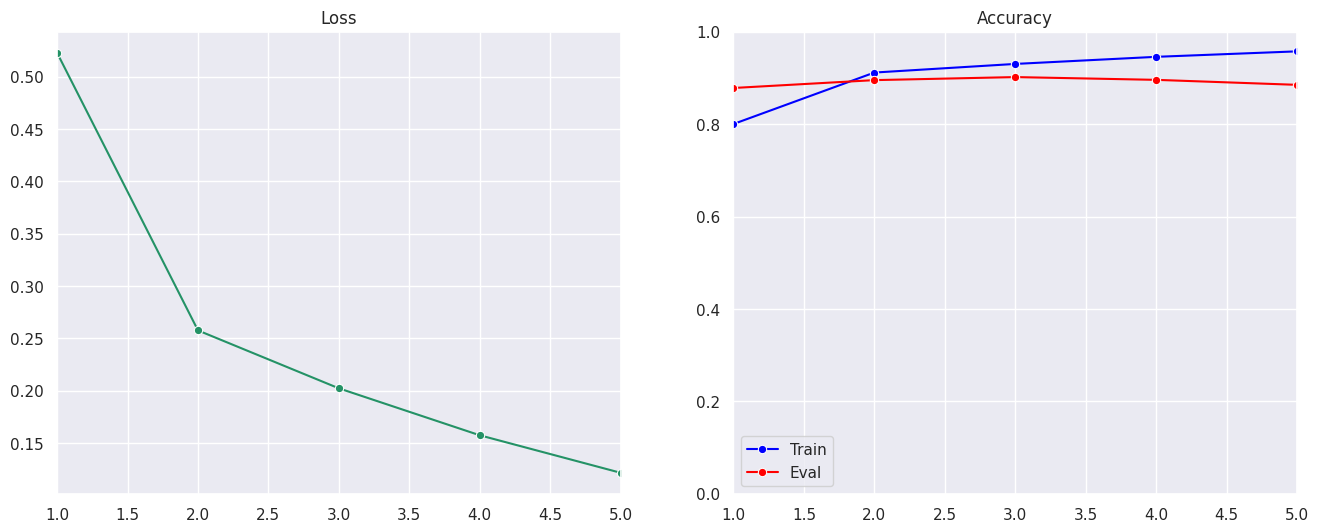

Total accuracy: 0.8852


([np.float64(0.5227170087423426),
  np.float64(0.2577108586002997),
  np.float64(0.2024212471956499),
  np.float64(0.15761013368519794),
  np.float64(0.12179193600959576)],
 [0.8783999681472778,
  0.8953999876976013,
  0.9019999504089355,
  0.8959999680519104,
  0.8851999640464783])

In [ ]:
# Запуск бейзлайна -- скор 0.8852
model0 = baseline(11842, 256, nn.RNN, "max").to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model0.parameters())
train_loop(model0, 5, criterion, optimizer)

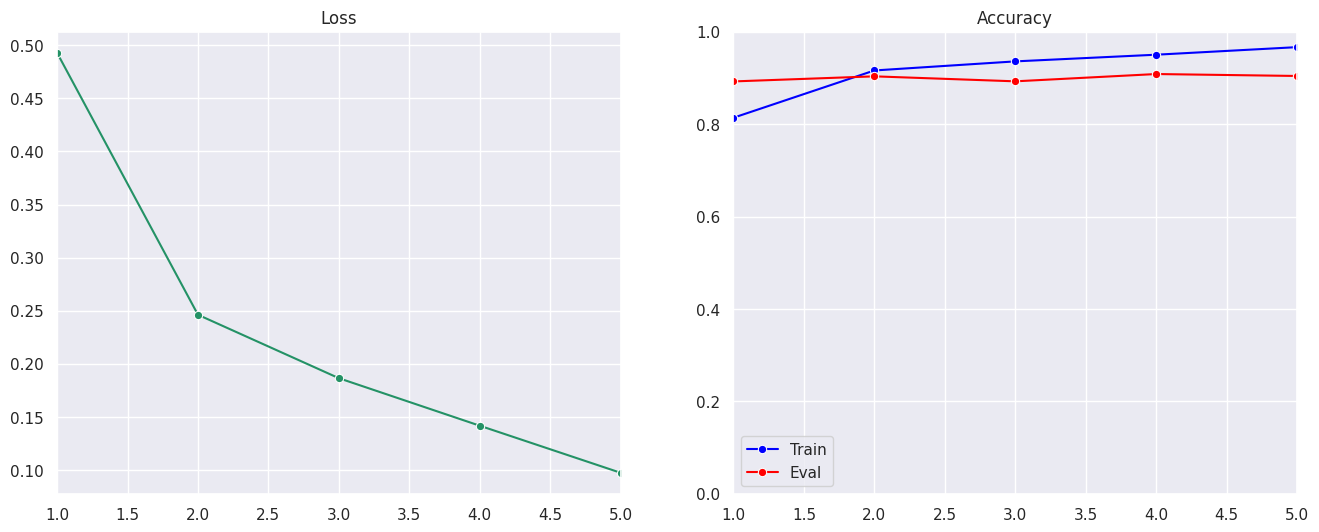

Total accuracy: 0.9044


([np.float64(0.4929137028253542),
  np.float64(0.24623918607041187),
  np.float64(0.18651408604724667),
  np.float64(0.14176758212883145),
  np.float64(0.09743786201723473)],
 [0.8925999999046326,
  0.9035999774932861,
  0.892799973487854,
  0.9085999727249146,
  0.9043999910354614])

In [ ]:
# Эксперимент 1 -- GRU, скор 0.9044
model1 = baseline(11842, 256, nn.GRU, "max").to(device)
optimizer = torch.optim.Adam(model1.parameters())
train_loop(model1, 5, criterion, optimizer)

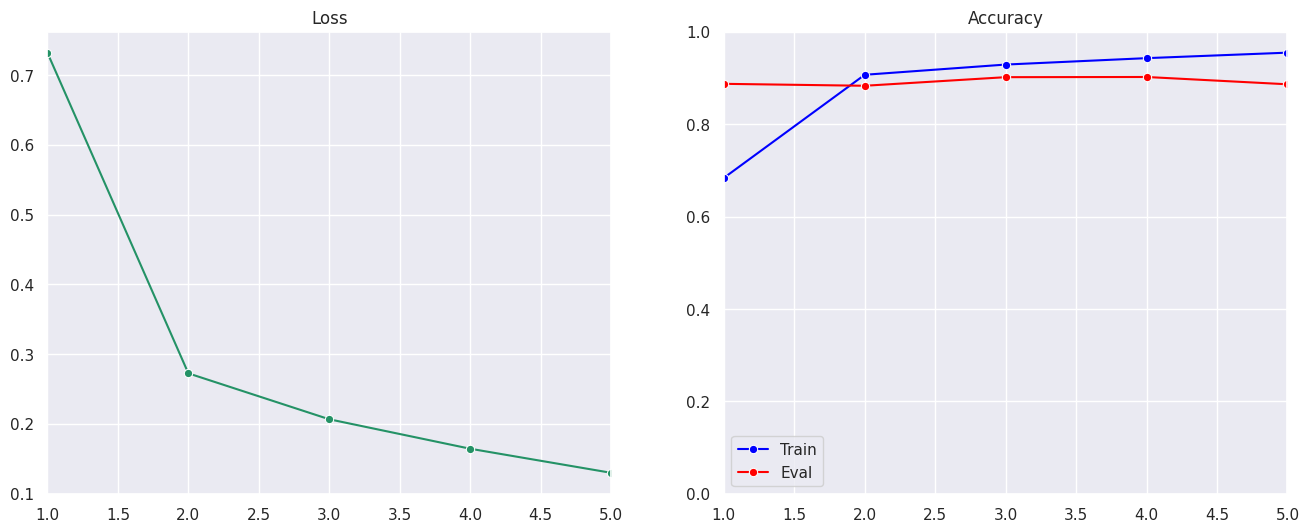

Total accuracy: 0.8864


([np.float64(0.7320365671976716),
  np.float64(0.27247777839220877),
  np.float64(0.20662437500465042),
  np.float64(0.16439632550145206),
  np.float64(0.12988147508129214)],
 [0.8873999714851379,
  0.8831999897956848,
  0.9017999768257141,
  0.9021999835968018,
  0.8863999843597412])

In [ ]:
# Эксперимент 2 -- конкатенация последнего выхода рнн и макспулинга скор 0.8864
model2 = advanced(11842, 256, nn.RNN, "max").to(device)
optimizer = torch.optim.Adam(model2.parameters())
train_loop(model2, 5, criterion, optimizer)

In [13]:
#Эксперимент 3 - добавляем слои
class multilayer(baseline):
    def __init__(self, vocab_size: int, hidden_dim: int, worker, num_layers: int, aggregation_type: string):
        super().__init__(vocab_size, hidden_dim, worker, aggregation_type)
        self.worker = worker(hidden_dim, hidden_dim, batch_first=True, num_layers=num_layers)

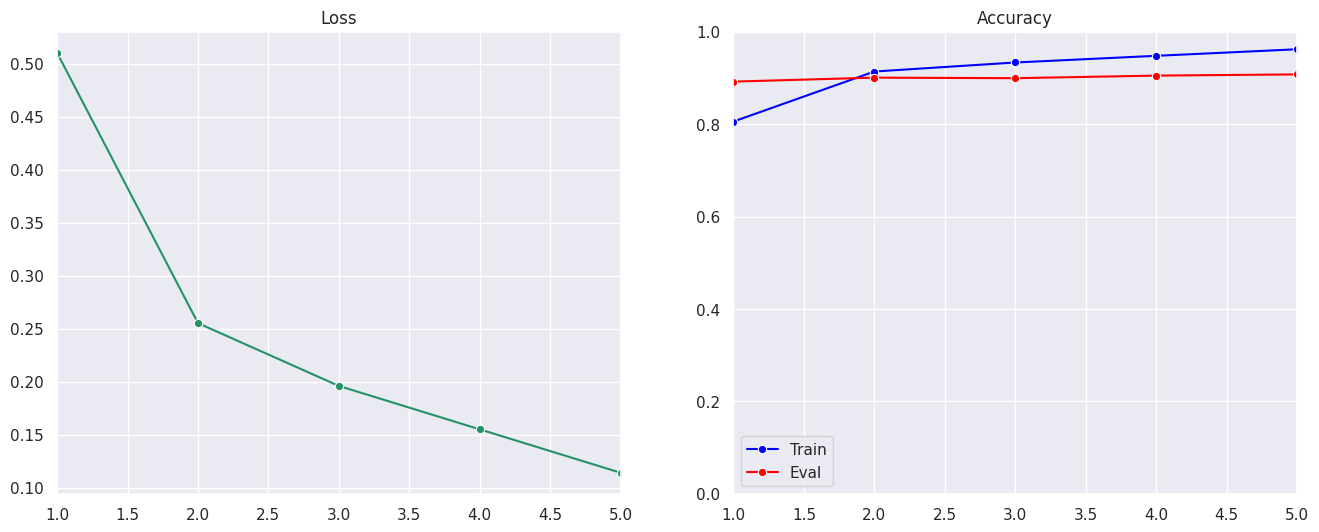

Total accuracy: 0.9078


([np.float64(0.5101291713676689),
  np.float64(0.2552997463583525),
  np.float64(0.19608136687704195),
  np.float64(0.15517299925059397),
  np.float64(0.11420941953103028)],
 [0.8921999931335449,
  0.9007999897003174,
  0.8995999693870544,
  0.9052000045776367,
  0.9077999591827393])

In [ ]:
model3 = baseline(11842, 256, nn.GRU, "max").to(device)
optimizer = torch.optim.Adam(model3.parameters())
train_loop(model3, 5, criterion, optimizer)

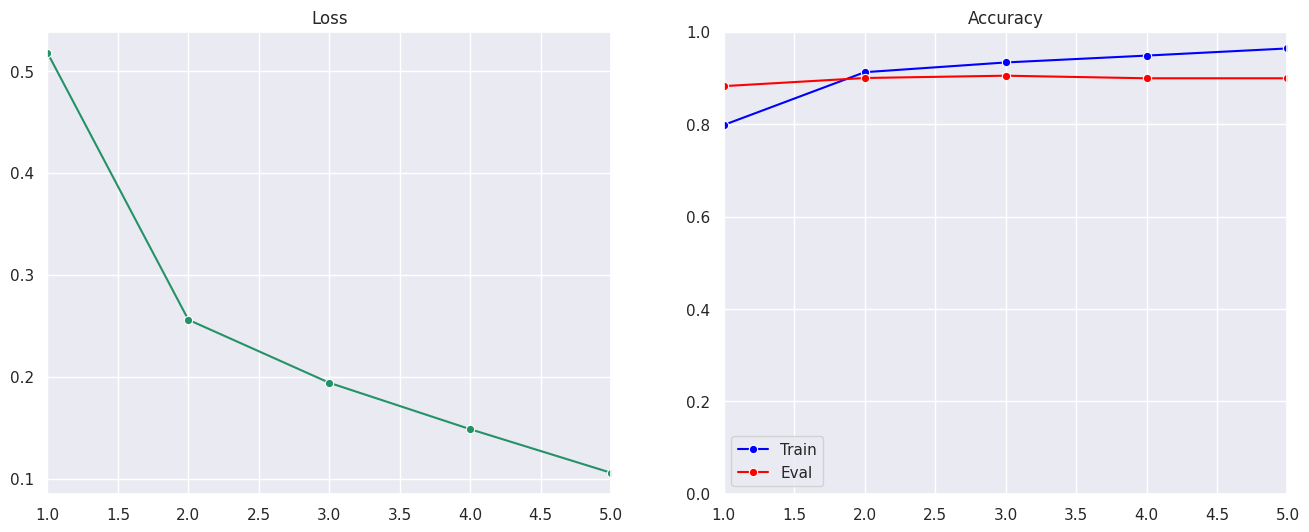

Total accuracy: 0.8994


([np.float64(0.5179603042956376),
  np.float64(0.25587953848257505),
  np.float64(0.19401394741695255),
  np.float64(0.14844929271578367),
  np.float64(0.1056279048270977)],
 [0.8823999762535095,
  0.8999999761581421,
  0.9049999713897705,
  0.899399995803833,
  0.899399995803833])

In [ ]:
# Эксперимент 3 -- скор 0.8994
model3 = multilayer(11842, 256, nn.GRU, 2, "max").to(device)
optimizer = torch.optim.Adam(model3.parameters())
train_loop(model3, 5, criterion, optimizer)

In [14]:
# Ещё эксперимент -- bidirectional модели
class advanced_bidir(advanced):
    def __init__(self, vocab_size, hidden_dim, worker, aggregation_type):
        super().__init__(vocab_size, hidden_dim, worker, aggregation_type)
        self.worker = worker(hidden_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.hidden_layer = nn.Linear(4 * hidden_dim, 4 * hidden_dim)
        self.projection = nn.Linear(4 * hidden_dim, 4)

Epoch: 6, accuracy 0.8987999558448792


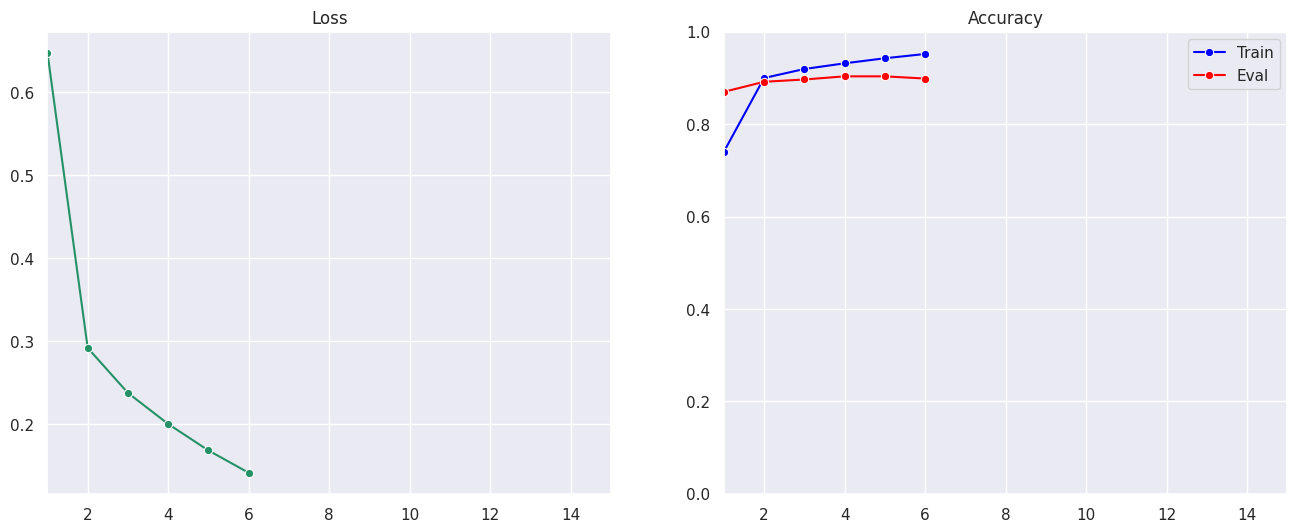

Training epoch 7::   0%|          | 0/283 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# GRU + конкатенация
model4 = advanced(11842, 128, nn.GRU, "max").to(device)
optimizer = torch.optim.Adam(model4.parameters())
train_loop(model4, 15, criterion, optimizer)

## Лучшая модель

Epoch: 50, accuracy 0.9147999882698059


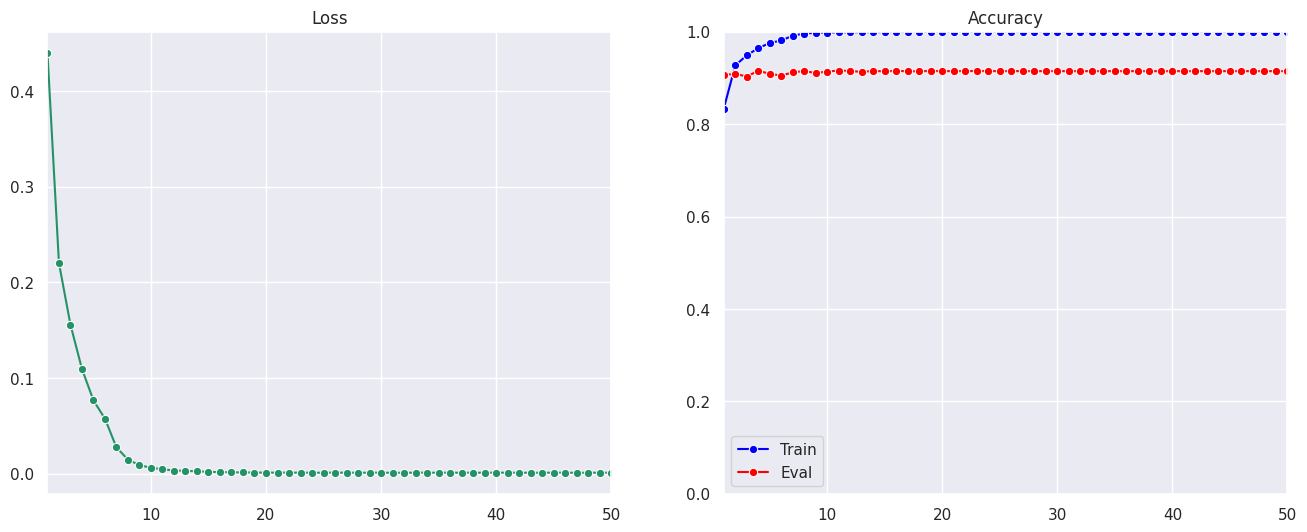

Total accuracy: 0.9148
Best accuracy: 0.9160


([np.float64(0.44033041116781535),
  np.float64(0.2202646178426221),
  np.float64(0.1558482673019171),
  np.float64(0.10951779543150526),
  np.float64(0.07654144096110636),
  np.float64(0.05745022536939359),
  np.float64(0.02731303648070025),
  np.float64(0.014641856406948742),
  np.float64(0.00881619413964169),
  np.float64(0.006070462484846454),
  np.float64(0.00446674865835727),
  np.float64(0.0032126178652940023),
  np.float64(0.0028033000513384347),
  np.float64(0.00241817652587694),
  np.float64(0.0017803225333030545),
  np.float64(0.0014881344002371103),
  np.float64(0.001320921226882395),
  np.float64(0.0011420375136973842),
  np.float64(0.001101779539802313),
  np.float64(0.0009053698038163323),
  np.float64(0.0009872239467161612),
  np.float64(0.0009690352812526726),
  np.float64(0.0009213991586724053),
  np.float64(0.0008266511760856095),
  np.float64(0.0009001955932224822),
  np.float64(0.0009542231111974313),
  np.float64(0.0009127029845785728),
  np.float64(0.000849620208

In [50]:
#Самый успешный эксперимент -- 0.916
model5 = advanced(27694, 256, nn.LSTM, "max").to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model5.parameters(), lr = 1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=1, factor=0.5)
train_loop(model5, 50, criterion, optimizer, scheduler)

In [51]:
from google.colab import files

torch.save(model5.state_dict(), "best_model.pth")
files.download("best_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
evaluate(model5, eval_dataloader)

0.9159999489784241

## Отчет
(В порядке увеличения accuracy)


*   По сравнению с бейзлайном лучший прирост качества дало использование GRU, затем я совместил GRU и конкатенацию пулинга и последнего выхода, повысил вероятность дропаута 0.1 -> 0.5, уменьшил трешхолд вхождения в словарь до 5, поставил lr = 1e-3 и scheduler уменьшающий lr в 2 раза как только приросста val accuracy не наблюдается затем увеличил дропаут до 0.75 и затем, заменив GRU на LSTM получил лучший результат.

*   Из указанных гиперпараметров на результат не очень влияет только hidden_dim, замена RNN на GRU/LSTM, конкатенация, vocab_size и dropout_rate дают основной прирост качества, увеличение RNN - слоев только замедляет обучение и в целом ухудшает качество.

*   Во всех случаях лучший результат наблюдался в пределах 5й эпохи, то есть сходимость довольно быстрая, но поначалу очень нестабильная; заметное переобучение